# SER Analysis — Starter (example) Notebook

Each week you need to create separate notebook and do some analysis. You create additional notebooks in this `notebooks/` folder for each stage of your analysis (e.g., EDA, classification, clustering, etc.).

In [14]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score, mean_squared_error, log_loss

# Audio
import librosa
import librosa.display

# MiniLearn — your from-scratch library
# from minilearn.classifiers import LogisticRegression, KNN, GaussianNaiveBayes, DecisionTreeClassifier
# from minilearn.preprocessing import StandardScaler, train_test_split
# from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

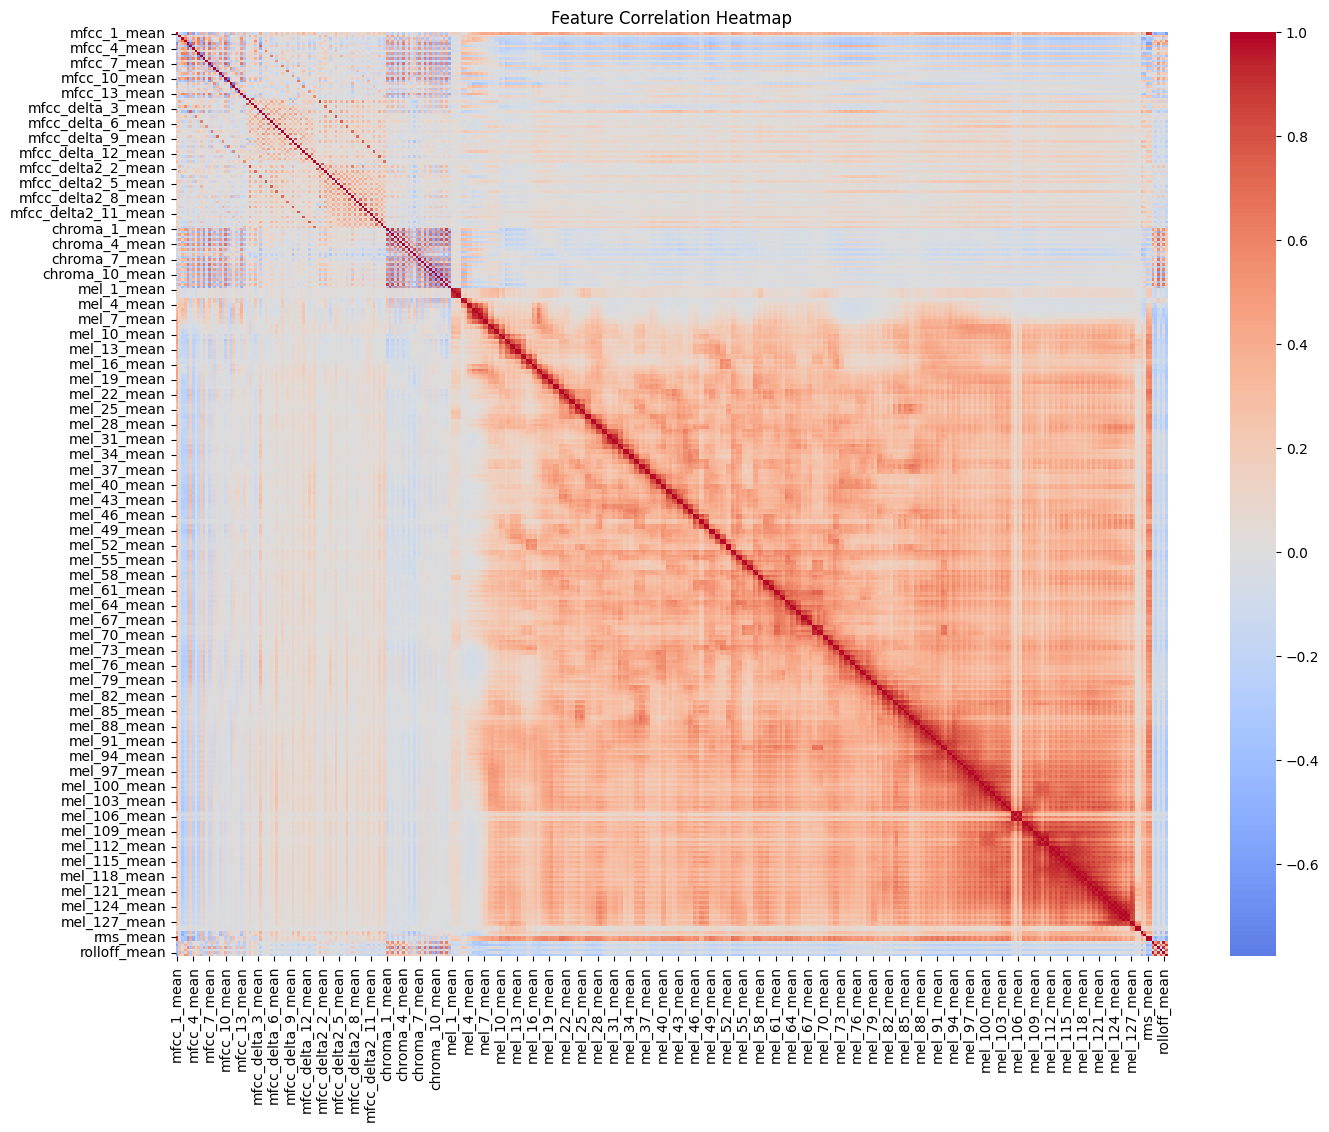

mel_128_mean       mel_128_std           0.994484
mel_125_mean       mel_126_mean          0.992422
mel_34_mean        mel_34_std            0.990307
mel_47_mean        mel_47_std            0.988488
mel_125_std        mel_126_std           0.988125
                                           ...   
mel_9_mean         mel_10_std            0.779570
mel_23_std         mel_24_std            0.778992
mel_87_mean        mel_89_std            0.778742
mel_95_mean        mel_99_mean           0.778671
mfcc_delta_12_std  mfcc_delta2_12_std    0.778476
Length: 1000, dtype: float64


In [4]:
# Heatmap to show degree of correlation between features

corr = features.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# get the correlation matrix of the numeric features and take the absolute value
# since negative correlations are just as significant
corr_matrix = features.corr().abs()

# Excludes duplicate comparisons with the bottom triangle and self-comparisons along the diagonal
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Gets the 1000 most highly correlated features
top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(1000)
)

print(top_pairs)

There is high correlation between mel means and stds, as well as correlation between closely numbered mel values. The same can be said with chroma means and stds. It's hard to tell what other correlations exist because of the quantity of features. I'll need to reduce the features for better analysis.

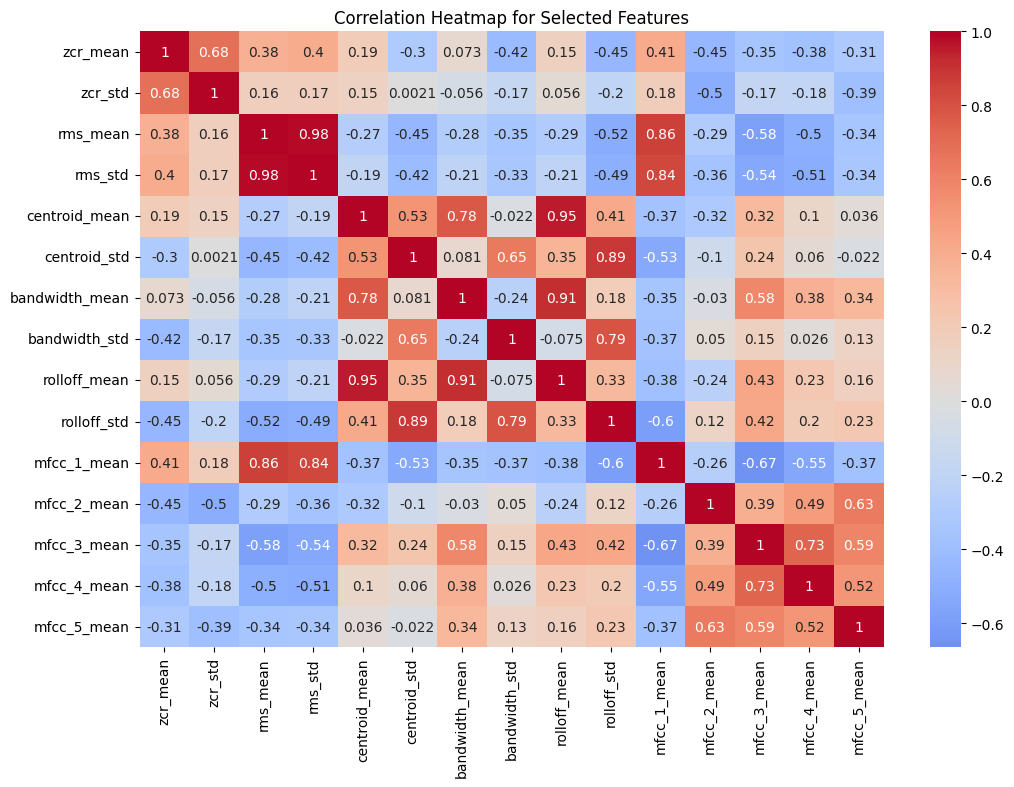

rms_mean        rms_std           0.980671
centroid_mean   rolloff_mean      0.952076
bandwidth_mean  rolloff_mean      0.911663
centroid_std    rolloff_std       0.888374
rms_mean        mfcc_1_mean       0.861276
rms_std         mfcc_1_mean       0.836122
bandwidth_std   rolloff_std       0.789441
centroid_mean   bandwidth_mean    0.776484
mfcc_3_mean     mfcc_4_mean       0.730588
zcr_mean        zcr_std           0.678418
mfcc_1_mean     mfcc_3_mean       0.665269
centroid_std    bandwidth_std     0.647033
mfcc_2_mean     mfcc_5_mean       0.630224
rolloff_std     mfcc_1_mean       0.596683
mfcc_3_mean     mfcc_5_mean       0.592019
rms_mean        mfcc_3_mean       0.583897
bandwidth_mean  mfcc_3_mean       0.582182
mfcc_1_mean     mfcc_4_mean       0.550367
rms_std         mfcc_3_mean       0.541495
centroid_std    mfcc_1_mean       0.534085
dtype: float64


In [5]:
# get a small subset of features to make analysis easier
selected = [
    "zcr_mean", "zcr_std",
    "rms_mean", "rms_std",
    "centroid_mean", "centroid_std",
    "bandwidth_mean", "bandwidth_std",
    "rolloff_mean", "rolloff_std",
    "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean", "mfcc_5_mean"
]

corr_small = df[selected].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_small, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Selected Features")
plt.show()

corr_small_matrix = corr_small.abs()

upper = corr_small_matrix.where(
    np.triu(np.ones(corr_small_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(20)
)

print(top_pairs)

There's a high coorelation betwen centroid, rolloff, and bandwidth, as well as rms and mfcc.

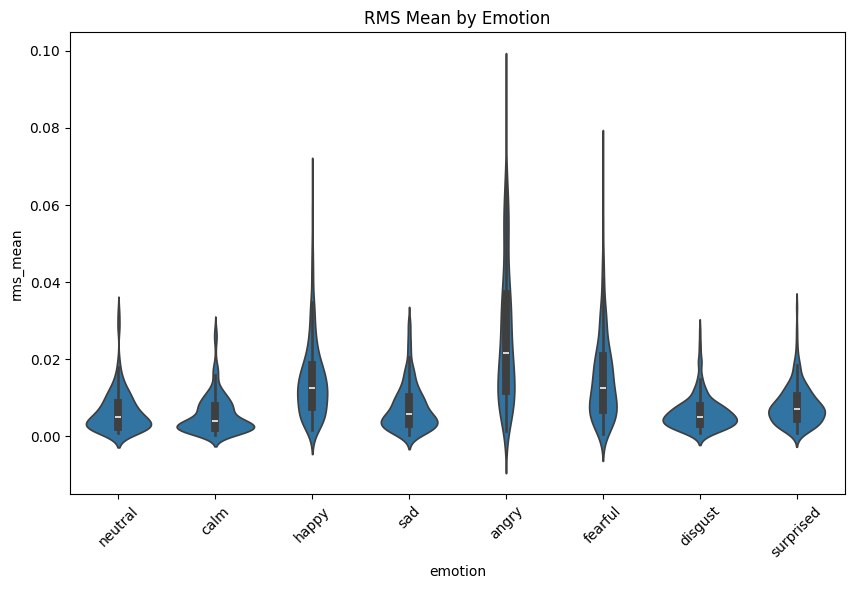

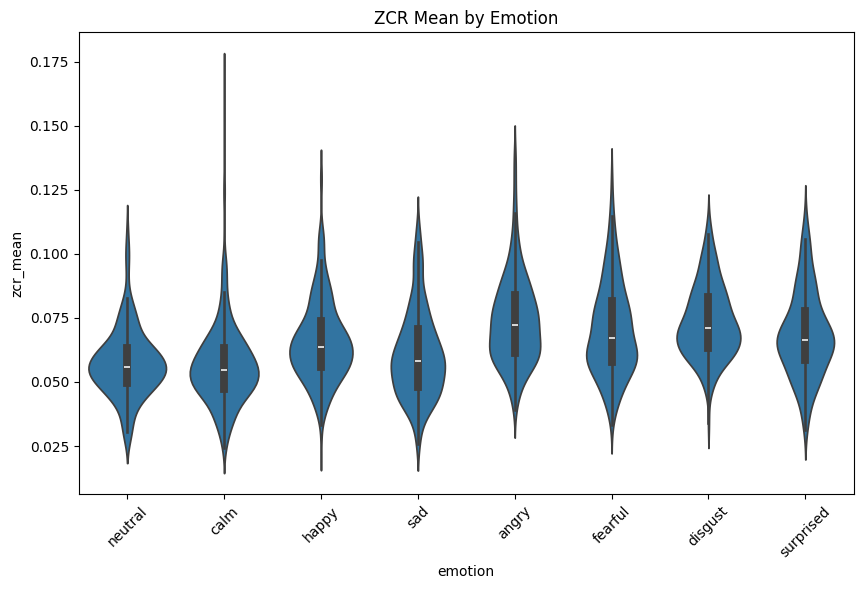

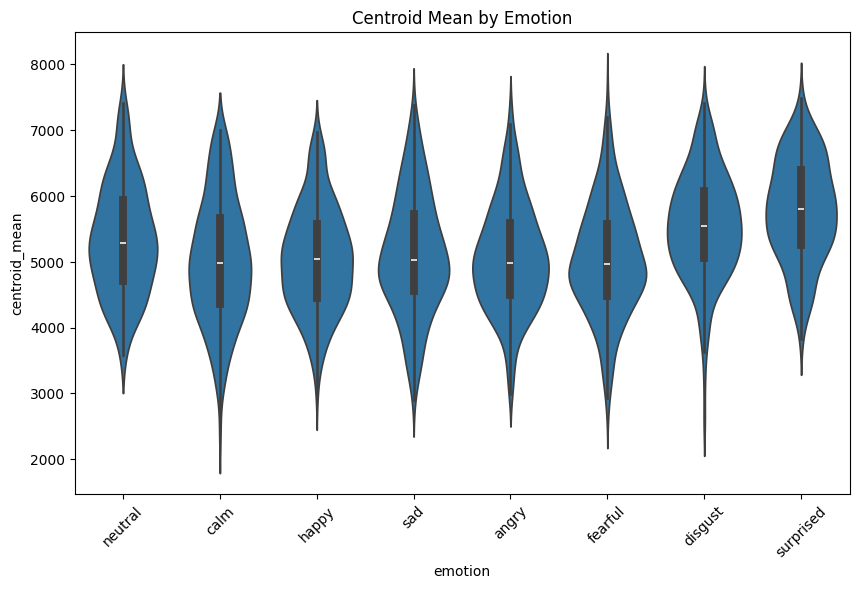

In [6]:
# RMS mean to show volume
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="rms_mean")
plt.title("RMS Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

# ZCR mean to show sudden changes in volume
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="zcr_mean")
plt.title("ZCR Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

# Centroid mean to show audio brightness
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="centroid_mean")
plt.title("Centroid Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

The differences seen with RMS mean are quite significant. In particular, happy, angry, and fearful all had a very wide spread of volume with out a clear spike of frequency at a particular value like seen with the other emotions. These three features also had the highest highs and lowest lows, as well as the highest means.

ZCR shows that calm has the lowest (and also somehow the highest?) sudden changes in volume. Calm containing the highest sudden change is clearly an outlier. Angry has the highest mean.

Centroid mean shows surprised, disgust, and neutral as having the brightest sound on average, which I wouldn't have expected. It seems odd that happy is one of the lowest.

In [7]:
df.groupby("emotion")[["rms_mean", "zcr_mean", "centroid_mean"]].mean()

,rms_mean,zcr_mean,centroid_mean
emotion,,,
angry,0.026199,0.073973,5061.024069
calm,0.005696,0.056520,5022.000141
disgust,0.006165,0.073492,5553.440437
fearful,0.015218,0.070437,5026.912565
happy,0.014723,0.065909,5044.078861
neutral,0.006472,0.057340,5334.386507
sad,0.007538,0.060726,5106.891183
surprised,0.008045,0.068609,5780.533526


Reaffirms my analysis

In [ ]:
# Predicting emotion with features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [ ]:
# Baseline model

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.635139845562833
Recall: 0.6380026990553306
Macro F1: 0.6356107342023884
Log Loss 1.4252414617944464
[[50  0  3  5  6  1  6  4]
 [ 0 58  2  0  3  2 10  0]
 [ 5  2 23  0  1  2  2  4]
 [ 9  2  1 45  5  0  9  4]
 [ 8  2  1  8 46  4  5  1]
 [ 0  2  0  1  2 28  4  1]
 [ 1 14  4  7  1  5 42  1]
 [ 1  3  6  3  3  0  1 22]]


Log loss for 8 classifications would give a value around 2.079 if the model was guessing at complete random. This means the model is actually improving prediction, though not a whole lot. Preferrably this value would be closer to 0.

In [ ]:
# Predicting emotional intensity from features

X = features.copy()
y = df["intensity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [18]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7515274949083504
Precision: 0.756438557763061
Recall: 0.7442430917100521
Macro F1: 0.7455915330252787
Log Loss 0.5159395773569019
[[222  42]
 [ 80 147]]


The model is much better at classifying intensity than emotion type! Though, this is to be expected as there are only 3 classifications.

In [ ]:
# Predicting actor gender from features

X = features.copy()
y = df["actor_gender"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [20]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9918533604887984
Precision: 0.9919555688384141
Recall: 0.9917759336099585
Macro F1: 0.9918492695883134
Log Loss 0.016464854502058424
[[238   3]
 [  1 249]]


The model is nearly perfect at classifying the gender of an actor!